In [1]:
import requests
import geopandas as gpd
import pandas as pd
from typing import Final


## Пример загрузки потенциала проекта из бд

In [2]:
# URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

# #211
# #198
# #124
# #335

# id = 198

# scenario_response = requests.get(
#     f"{URBAN_API}/scenarios/{id}", verify=False
# )
# if scenario_response.status_code != 200:
#     raise Exception("Ошибка при получении информации по сценарию")

# scenario_data = scenario_response.json()
# project_id = scenario_data.get("project", {}).get("project_id")
# if project_id is None:
#     raise Exception("Project ID is missing in scenario data.")

# territory_response = requests.get(
#     f"{URBAN_API}/projects/{project_id}/territory", verify=False
#         )

# if territory_response.status_code != 200:
#             raise Exception("Ошибка при получении геометрии территории")
        
# territory_data = territory_response.json()
# territory_geometry = territory_data["geometry"]
# territory_feature = {
#     'type': 'Feature',
#     'geometry': territory_geometry,
#     'properties': {}
# }
# polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
# polygon_gdf = polygon_gdf.to_crs(32636)


# scenario_indicators_response = requests.get(
#     f"{URBAN_API}/scenarios/{id}/indicators_values", verify=False
# )
# if scenario_response.status_code != 200:
#     raise Exception("Ошибка при получении информации по сценарию")

# scenario_indicators = scenario_indicators_response.json()

# indicator_attributes = {
#     indicator['indicator']['name_full']: indicator['value']
#     for indicator in scenario_indicators
# }

# # Добавляем эти значения как колонки в polygon_gdf
# for name, value in indicator_attributes.items():
#     polygon_gdf[name] = value

# polygon_gdf['Потенциал развития жилой застройки'] = 4

# LAND_USE_TO_POTENTIAL_COLUMN: Final[dict[str, str]] = {
#     "residential": "Потенциал развития жилой застройки",
#     "business":     "Потенциал развития застройки общественно-деловой зоны",
#     "recreation":   "Потенциал развития застройки рекреационной зоны",
#     "special":      "Потенциал развития застройки зоны специального назначения",
#     "industrial":   "Потенциал развития застройки промышленной зоны",
#     "agriculture":  "Потенциал развития застройки сельскохозяйственной зоны",
#     "transport":    "Потенциал развития застройки транспортной зоны",
# }

# records = []
# for _, row in polygon_gdf.iterrows():
#     for ip_type, col_name in LAND_USE_TO_POTENTIAL_COLUMN.items():
#         records.append({
#             "ip_type":  ip_type,
#             "ip_value": row[col_name],
#             "geometry": row.geometry
#         })

# # Создаём новый GeoDataFrame
# base_gdf = gpd.GeoDataFrame(records, crs=polygon_gdf.crs)
# base_gdf = base_gdf.reset_index(drop=True)
# base_gdf



In [3]:
# base_gdf.to_file('./data/project_potential.geojson', driver='GeoJSON')

In [4]:
from urbanomy.methods.investment_potential import prepare_investment_input

project_potential=gpd.read_file('./data/project_potential.geojson').to_crs(32636)
scenario_blocks = pd.read_pickle('./data/blocks_with_price.pickle').to_crs(32636)

polygon_input = prepare_investment_input(
    gdf = scenario_blocks,
    project_potential = project_potential,
)

# polygon_input.plot().axis('off')


In [5]:
polygon_input.head()


,geometry,land_use,price_pred,site_area,living_area,non_living_area,build_floor_area,share,ip_value,price_per_sotka
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",AGRICULTURE,3.162043e+08,202399.732193,0.000000,12550.410318,12550.410318,0.918180,3.0,0.0
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",BUSINESS,3.591473e+08,201529.493481,0.000000,40777.536145,40777.536145,0.938081,2.0,0.0
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",TRANSPORT,2.299947e+08,164663.859830,0.000000,24985.649917,24985.649917,0.891381,4.0,0.0
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",RESIDENTIAL,6.735948e+08,161571.832511,29356.900162,43211.792478,72568.692640,0.934862,4.0,0.0
4,"POLYGON ((388000.75 6643199.606, 388001.306 66...",RESIDENTIAL,4.901846e+04,49.926816,0.678864,1.491125,2.169989,0.132440,4.0,0.0


## Инвевстиционная привлекательность

In [10]:
benchmarks_demo = {
    "RESIDENTIAL": {
        "cost_build": 45_000,
        "price_sale": 110_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    "BUSINESS": {
        "cost_build": 55_000,
        "rent_annual": 34_000,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 1300,
    },
    "RECREATION": {
        "cost_build": 20_000,
        "rent_annual": 8_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1000,
    },
    "SPECIAL": {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1500,
    },
    "INDUSTRIAL": {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    "AGRICULTURE": {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    "TRANSPORT": {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [11]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
gdf_out, summary = an.calculate_investment_metrics(polygon_input)
summary


,land_use,land_area,built_area,land_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,AGRICULTURE,"202,399.73","12,550.41","316,204,289.31","313,760,257.95","629,964,547.26","-324,407,187.61",0.06,2.04,NaN,0.00,3.00,21.36
1,BUSINESS,"201,529.49","40,777.54","359,147,260.99","2,242,764,487.95","2,601,911,748.94","2,017,498,199.38",0.33,12.18,6.71,100.00,2.00,57.27
2,TRANSPORT,"164,663.86","24,985.65","229,994,728.96","449,741,698.50","679,736,427.46","-1,623,744.51",0.18,5.83,NaN,0.00,4.00,42.73
3,RESIDENTIAL,"161,571.83","72,568.69","673,594,837.34","3,265,591,168.79","3,939,186,006.12","597,968,888.74",0.24,3.20,5.47,75.04,4.00,85.70
4,RESIDENTIAL,49.93,2.17,"49,018.46","97,649.50","146,667.96","-10,995.46",0.15,2.06,NaN,0.00,4.00,42.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,AGRICULTURE,2.67,NaN,"15,413.50",NaN,"15,413.50","-11,960.46",0.15,5.41,NaN,0.00,3.00,21.36
64,TRANSPORT,"4,307.66",688.58,"6,523,570.52","12,394,368.01","18,917,938.54","157,298.38",0.18,5.88,17.45,0.72,4.00,43.14
65,BUSINESS,61.63,13.49,"19,613.16","741,798.99","761,412.15","864,211.28",0.39,17.98,5.82,88.00,2.00,50.40
66,SPECIAL,175.85,60.89,"66,369.40","2,131,233.58","2,197,602.98","226,284.33",0.20,9.34,13.33,9.10,4.00,47.94


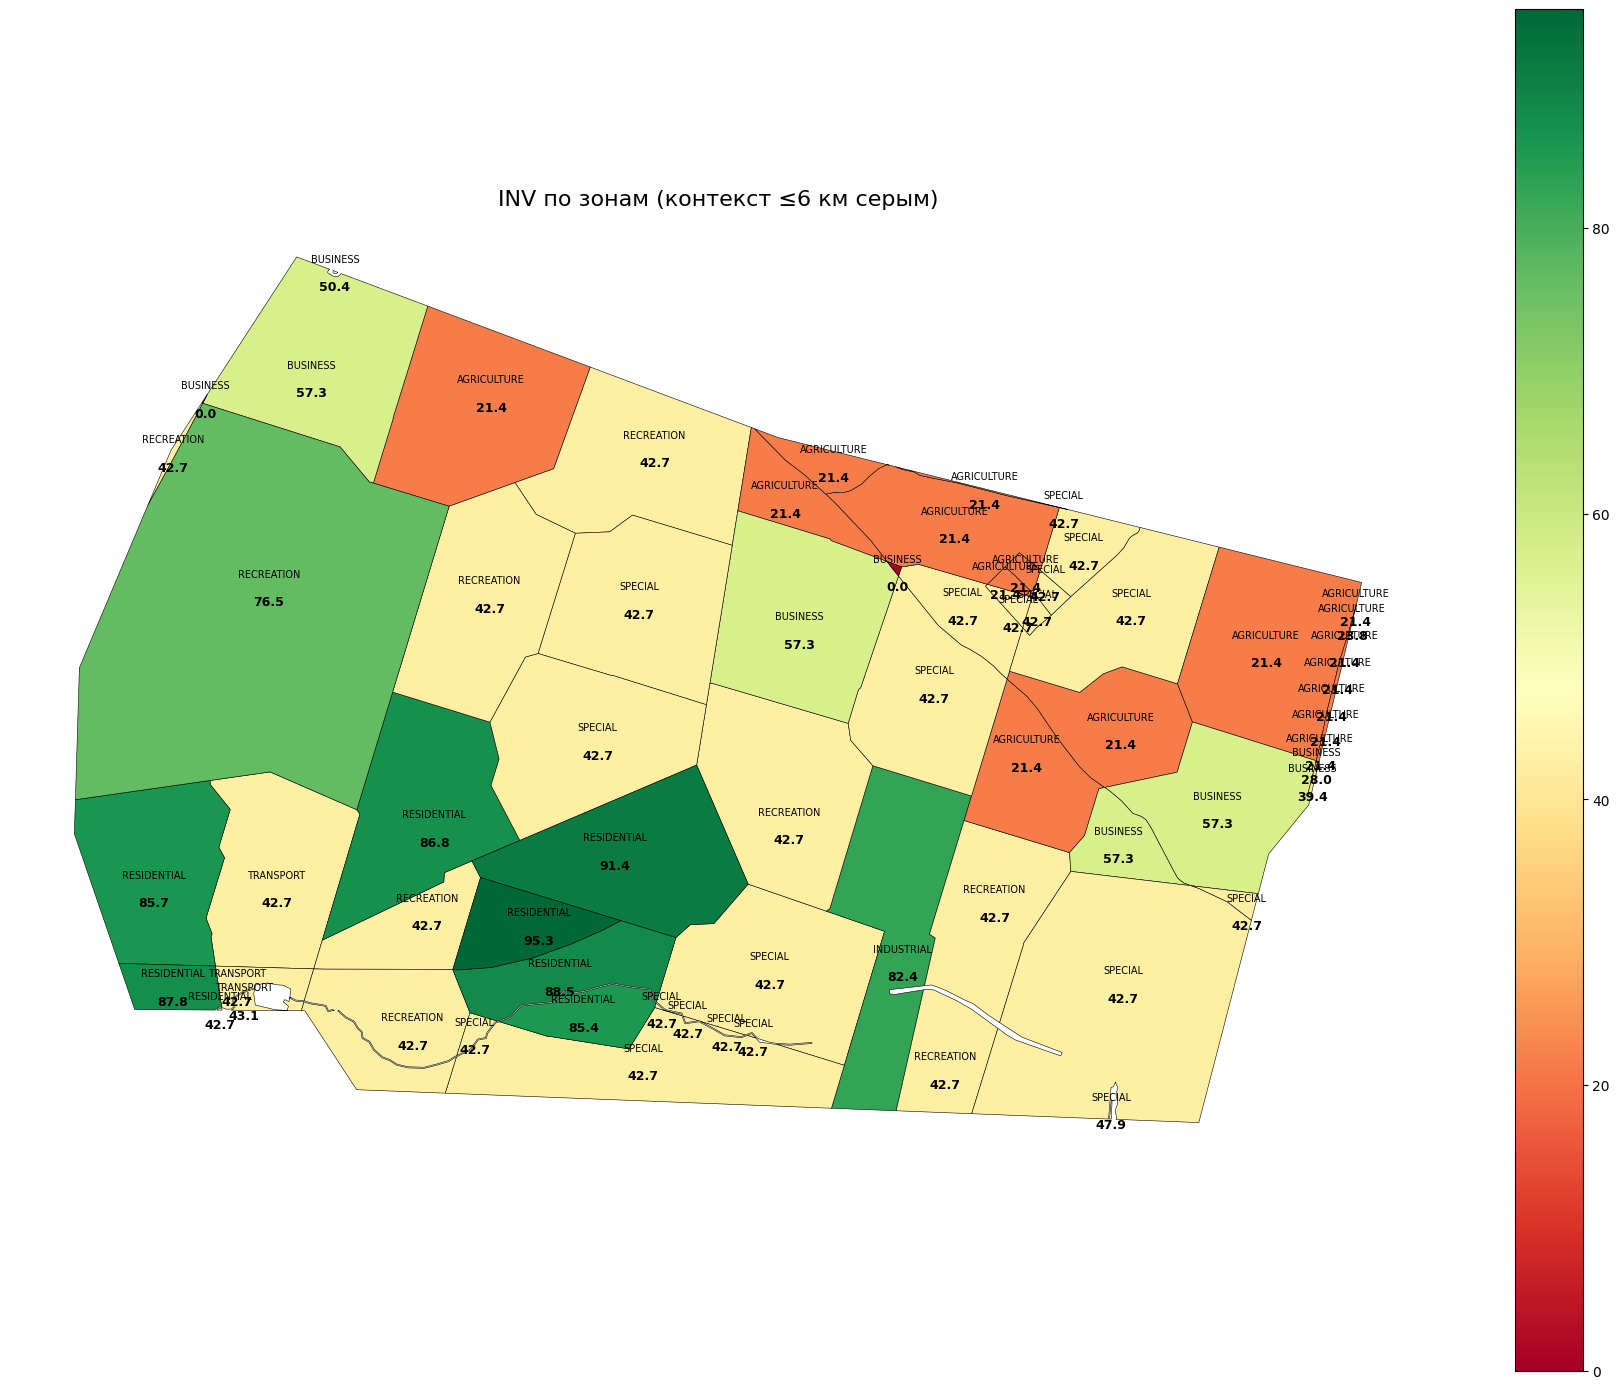

In [12]:
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
import matplotlib.ticker as mticker

def make_buffer_m(gdf, radius_m):
    g = gpd.GeoDataFrame(geometry=[gdf.geometry.union_all()], crs=gdf.crs)
    if g.crs and g.crs.is_geographic:
        utm = g.estimate_utm_crs()
        g = g.to_crs(utm); g['geometry'] = g.buffer(radius_m); g = g.to_crs(scenario_blocks.crs)
    else:
        g['geometry'] = g.buffer(radius_m)
    return g


# Разделяем на сценические и контекст
scn = gdf_out
# ctx = scenario_blocks[~scenario_blocks['is_scn']].copy()

# # Буфер вокруг сценических
# buf6_gdf = make_buffer_m(scn, 1500)
# context_6km = gpd.clip(ctx, buf6_gdf)

# Настройка шкалы
vmin, vmax = scn['INV'].min(), scn['INV'].max()

fig, ax = plt.subplots(figsize=(18, 14))

# # Контекст серым
# context_6km.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2, zorder=1)

# Сценические цветом
scn.plot(column='INV', cmap='RdYlGn', vmin=vmin, vmax=vmax,
         edgecolor='black', linewidth=0.4, legend=True, ax=ax, zorder=2)

# Подписи
for _, row in scn.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(x, y, row['land_use'], ha='center', va='bottom', fontsize=7,
            color='black', transform=offset_copy(ax.transData, fig=fig, y=6, units='points'), zorder=3)
    ax.text(x, y, f"{row['INV']:.1f}", ha='center', va='top', fontsize=9, fontweight='bold',
            color='black', transform=offset_copy(ax.transData, fig=fig, y=-6, units='points'), zorder=3)

ax.set_title('INV по зонам (контекст ≤6 км серым)', fontsize=16)
ax.axis('off')

# Красивый формат легенды
cbar_ax = fig.axes[-1]
cbar_ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)

plt.tight_layout()
plt.show()


In [ ]:
gdf_out.to_file('./data/blocks_investment.geojson', driver='GeoJSON')